In [1]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
from norm import norm
import os

In [2]:
folder_name = input('请输入保存模型的文件夹名称（若不存在则新建）')

请输入保存模型的文件夹名称（若不存在则新建）model12


In [3]:
# 对比结果等的存储路径
result_path = '../result/'
# 训练好的模型保存路径
model_path = '../trained_model/'

In [4]:
if not os.path.exists(result_path + folder_name):
    os.mkdir(result_path + folder_name)
    #创建几个子文件夹
    os.mkdir(result_path + folder_name + '/fuds')
    os.mkdir(result_path + folder_name + '/dst')
    os.mkdir(result_path + folder_name + '/us06')
    os.mkdir(result_path + folder_name + '/bjdst')

In [5]:
if not os.path.exists(model_path + folder_name):
    os.mkdir(model_path + folder_name)
    #子文件夹
    os.mkdir(model_path + folder_name + '/train')
    os.mkdir(model_path + folder_name + '/weights')
    os.mkdir(model_path + folder_name + '/param')

In [6]:
data_path = '../../data/net_data/'
save_path = '../trained_model/'+folder_name+'/'
seq_len = 30
sigma_iu = 0.0001
adp_iu = True

训练数据的产生分以下几步：  
1. 将数据按时间步划分
2. 给数据的特征添加噪声
3. 归一化

导入数据

In [7]:
data1 = pd.read_excel(data_path + 'SP2_25C_FUDS/fuds_80.xlsx').values
data2 = pd.read_excel(data_path + 'SP2_25C_DST/dst_80.xlsx').values
data3 = pd.read_excel(data_path + 'SP2_25C_BJDST/bjdst_80.xlsx').values
data4 = pd.read_excel(data_path + 'SP2_25C_US06/us06_80.xlsx').values
data5 = pd.read_excel(data_path + 'OTHER_DATA/incre.xlsx').values

将数据按时间步划分

In [8]:
def split(data, seq_len): 
    """交替划分"""
    data1 = []
    for i in range(len(data) - seq_len):
        data1.append(data[i: i + seq_len, :])
    data2 = np.array(data1)
    """划分x和y"""
    x = np.round(data2[:, :, 0:-1] * 1000)
    y = data2[:, -1, -1]
    data_dict = {'iu': x, 'soc_real': y}  
    return data_dict

In [9]:
data_dict1 = split(data1, seq_len=seq_len)
data_dict2 = split(data2, seq_len=seq_len)
data_dict3 = split(data3, seq_len=seq_len)
data_dict4 = split(data4, seq_len=seq_len)
data_dict5 = split(data5, seq_len=seq_len)

In [10]:
data_dict = {}
for key in data_dict1.keys():
    data_dict[key] = np.concatenate((data_dict1[key], \
                                data_dict2[key], \
                                data_dict3[key], \
                                data_dict4[key], \
                                data_dict5[key]), axis=0)

In [11]:
print(data_dict['iu'].shape)
print(data_dict['soc_real'].shape)

(209874, 30, 2)
(209874,)


给划分好的数据添加噪声

In [12]:
import add_noise

In [13]:
iu_noise = np.zeros(data_dict['iu'].shape) 
for i in trange(data_dict['iu'].shape[0]):    
    iu_noise[i, :, :] = add_noise.add_noise_iu(data_dict['iu'][i, :, :], sigma_iu, adp_iu)

100%|█████████████████████████████████| 209874/209874 [00:23<00:00, 9003.69it/s]


In [14]:
print(iu_noise.shape)

(209874, 30, 2)


电流添加噪声对比

In [15]:
noise2 = iu_noise[:, 0, 0] - data_dict['iu'][:, 0, 0]

In [16]:
noise2

array([-0.14213574,  0.        ,  0.        , ...,  0.        ,
        0.        ,  0.        ])

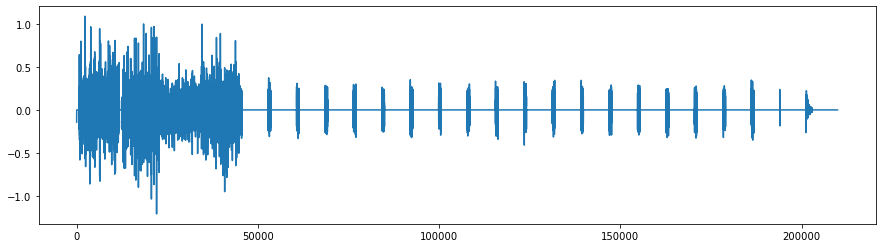

In [17]:
plt.figure(figsize=(15, 4))
plt.plot(noise2)
plt.show()

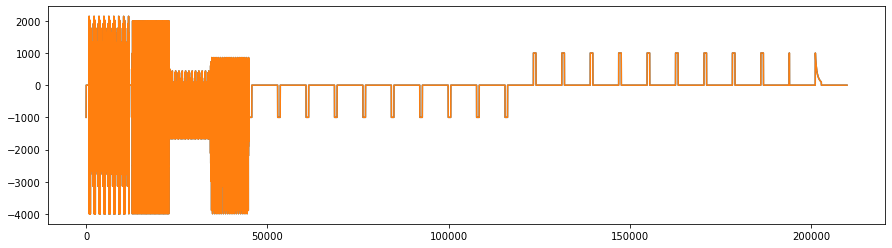

In [18]:
plt.figure(figsize=(15,4))
plt.plot(iu_noise[:, 0, 0])
plt.plot(data_dict['iu'][:, 0, 0])
plt.show()

电压添加噪声

In [19]:
noise3 = iu_noise[:, 0, 1] - data_dict['iu'][:, 0, 1]

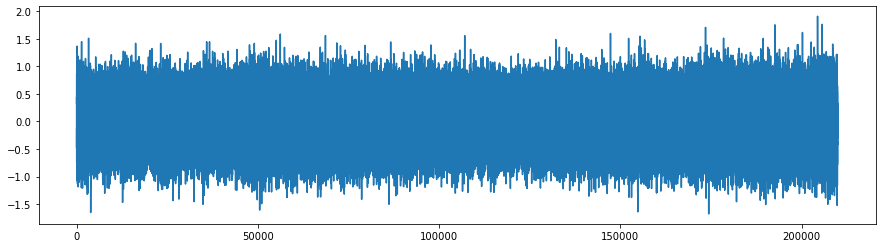

In [20]:
plt.figure(figsize=(15, 4))
plt.plot(noise3)
plt.show()

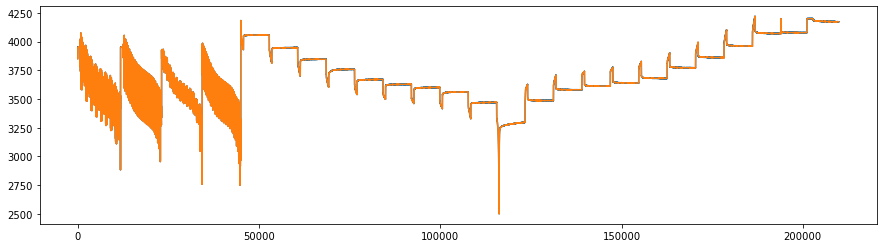

In [21]:
plt.figure(figsize=(15,4))
plt.plot(iu_noise[:, 0, 1])
plt.plot(data_dict['iu'][:, 0, 1])
plt.show()

划分训练集和测试集

In [22]:
y = np.repeat(data_dict['soc_real'].reshape(-1, 1), repeats=seq_len, axis=1)

In [23]:
y = y.reshape(-1, seq_len, 1)
xy = np.concatenate((data_dict['iu'], y), axis=2)

In [24]:
print(xy.shape)

(209874, 30, 3)


In [25]:
np.random.shuffle(xy)

In [26]:
split_p = int(xy.shape[0] * 0.75)

In [27]:
train_x = xy[:split_p, :, :-1]
train_y = xy[:split_p, 0, -1]
test_x = xy[split_p:, :, :-1]
test_y = xy[split_p:, 0, -1]

归一化

In [28]:
maxi = np.max(train_x, axis=(0, 1))
mini = np.min(train_x, axis=(0, 1))
norm_dict = {'max': maxi, 'min': mini}

In [29]:
train_x_nm = norm(train_x, norm_dict)
test_x_nm = norm(test_x, norm_dict)

In [30]:
xy_dict = {'train_x': train_x_nm, 'train_y': train_y, 'test_x': test_x_nm, 'test_y': test_y}

将本次训练的关键数据保存下来

In [31]:
np.save(save_path + 'train/norm_dict.npy', norm_dict)
np.save(save_path + 'train/xy_dict.npy', xy_dict)